# vanishing gradients

large models = gradients go to zero
- https://www.cs.toronto.edu/~rgrosse/courses/csc421_2019/slides/lec14.pdf

mathematically...

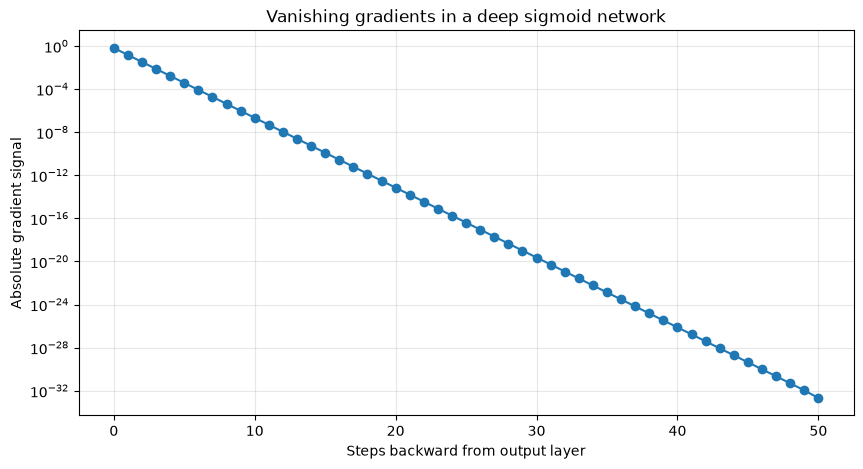

Depth: 50
Output activation: 0.659046
Loss: 0.217171

Gradient signal as we move backward:
Output layer gradient: 6.590e-01
Middle layer gradient: 4.066e-17
Input layer gradient:  2.129e-33


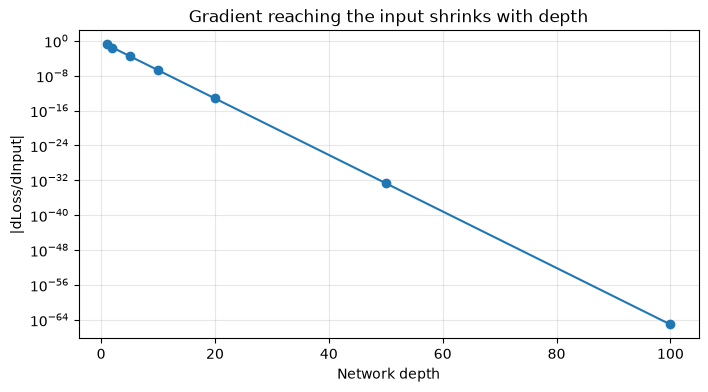

Depth   1: |dLoss/dInput| = 1.437e-01
Depth   2: |dLoss/dInput| = 2.911e-02
Depth   5: |dLoss/dInput| = 3.205e-04
Depth  10: |dLoss/dInput| = 1.835e-07
Depth  20: |dLoss/dInput| = 6.023e-14
Depth  50: |dLoss/dInput| = 2.129e-33
Depth 100: |dLoss/dInput| = 8.105e-66


In [1]:
import numpy as np

import matplotlib.pyplot as plt

def sigmoid(x):
	return 1 / (1 + np.exp(-x))

def sigmoid_derivative_from_activation(a):
	return a * (1 - a)

def run_deep_sigmoid_problem(depth, x=1.0, weight=1.0, bias=0.0, target=0.0):
	"""
	Scalar deep network:
		a_0 = x
		a_l = sigmoid(weight * a_{l-1} + bias)
		loss = 0.5 * (a_depth - target)^2

	Returns the gradient signal dLoss/da_l at every layer.
	"""
	activations = [x]
	preactivations = []

	# Forward pass
	a = x
	for _ in range(depth):
		z = weight * a + bias
		a = sigmoid(z)
		preactivations.append(z)
		activations.append(a)

	# Backward pass
	grad_at_activation = np.zeros(depth + 1)
	grad_at_activation[depth] = activations[-1] - target

	grad = grad_at_activation[depth]

	for layer in range(depth - 1, -1, -1):
		a_current = activations[layer + 1]
		dz = grad * sigmoid_derivative_from_activation(a_current)
		grad = dz * weight
		grad_at_activation[layer] = grad

	loss = 0.5 * (activations[-1] - target) ** 2
	return loss, np.array(activations), grad_at_activation

depth = 50
loss, activations, gradients = run_deep_sigmoid_problem(depth)

backward_distance = depth - np.arange(depth + 1)

plt.figure(figsize=(10, 5))
plt.semilogy(backward_distance, np.abs(gradients), marker="o")
plt.xlabel("Steps backward from output layer")
plt.ylabel("Absolute gradient signal")
plt.title("Vanishing gradients in a deep sigmoid network")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print(f"Depth: {depth}")
print(f"Output activation: {activations[-1]:.6f}")
print(f"Loss: {loss:.6f}")
print()
print("Gradient signal as we move backward:")
print(f"Output layer gradient: {gradients[-1]:.3e}")
print(f"Middle layer gradient: {gradients[depth // 2]:.3e}")
print(f"Input layer gradient:  {gradients[0]:.3e}")

depths = [1, 2, 5, 10, 20, 50, 100]
input_gradients = []

for d in depths:
	_, _, grads = run_deep_sigmoid_problem(d)
	input_gradients.append(abs(grads[0]))

plt.figure(figsize=(8, 4))
plt.semilogy(depths, input_gradients, marker="o")
plt.xlabel("Network depth")
plt.ylabel("|dLoss/dInput|")
plt.title("Gradient reaching the input shrinks with depth")
plt.grid(True, which="both", alpha=0.3)
plt.show()

for d, g in zip(depths, input_gradients):
	print(f"Depth {d:>3}: |dLoss/dInput| = {g:.3e}")